In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
r = 1.46e11
c = 3e8
def compute_fd_complex_response(f_gw, theta_1, ra, dec, iota, psi):
    # GW propagation vector
    positions = np.array([[r*np.cos(theta_1),r*np.sin(theta_1),0]])
    arms = np.array([[np.sin(theta_1),np.cos(theta_1),0]])
    arm_lengths = [1e10,1e10,1e10,1e10,1e10,1e10]
    arm_lengths = np.array(arm_lengths)

    theta= np.pi/2- dec
    phi = ra
    k = -np.array([
        np.sin(theta) * np.cos(phi),
        np.sin(theta) * np.sin(phi),
        np.cos(theta)
    ])
    # 1. Amplitudes
    A=1
    A_cross  = A*np.cos(iota)
    A_plus = A*(1+np.cos(iota)**2)/2
    def make_perp_basis(k):
        k = k / np.linalg.norm(k)
        if np.abs(k[2]) < 0.99:
            tmp = np.array([0,0,1])
        else:
            tmp = np.array([1,0,0])
        ex = np.cross(tmp, k)
        ex /= np.linalg.norm(ex)
        ey = np.cross(k, ex)
        return ex, ey

    ex, ey = make_perp_basis(k)

    # Polarization tensors
    e_plus = np.outer(ex, ex) - np.outer(ey, ey)
    e_cross = np.outer(ex, ey) + np.outer(ey, ex)

    # Rotate by polarization angle psi
    e_plus_rot  = e_plus * np.cos(2 * psi) + e_cross * np.sin(2 * psi)
    e_cross_rot = -e_plus * np.sin(2 * psi) + e_cross * np.cos(2 * psi)

    # --- CLOCK ANTENNA GEOMETRY ---
    # n̂ = photon propagation direction
    nk = np.einsum("di,i->d", arms, k)
    denom = 1.0 - nk

    # Geometry-only detector tensor
    D = 0.5 * np.einsum("di,dj->dij", arms, arms) / denom[:, None, None]

    # Antenna factors
    F_plus  = np.einsum("dij,ij->d", D, e_plus_rot)
    F_cross = np.einsum("dij,ij->d", D, e_cross_rot)


    # Keep original phase convention
    tau = np.dot(positions, k) / c
   
    phase_delay = 2 * np.pi * f_gw * arm_lengths * denom / c
    transfer = 1.0 - np.exp(-1j * phase_delay)
   
    # Pure antenna-pattern response (no transfer function)
    S = (F_plus * A_plus + 1j*F_cross * A_cross) * np.exp(-1j * 2 * np.pi * f_gw * tau) * transfer


    
    return S

In [3]:
f_gw = 0.010 

In [4]:
ra = 0.3
dec = 0.367
iota = np.pi/5
psi = 1.52


In [5]:
t = np.linspace(0,14,1000)

In [27]:
theta_1 = np.pi/3 + (t/(24)*1/365*1/8)*2*np.pi
theta_2 = np.pi/6 + (t/(24)*1/365*1/8)*2*np.pi

In [28]:
# theta_1

In [29]:
resps1 = []
for theta in theta_1:
    resps1.append(compute_fd_complex_response(f_gw, theta, ra, dec, iota, psi))
    
resps2 = []
for theta in theta_2:
    resps2.append(compute_fd_complex_response(f_gw, theta, ra, dec, iota, psi))

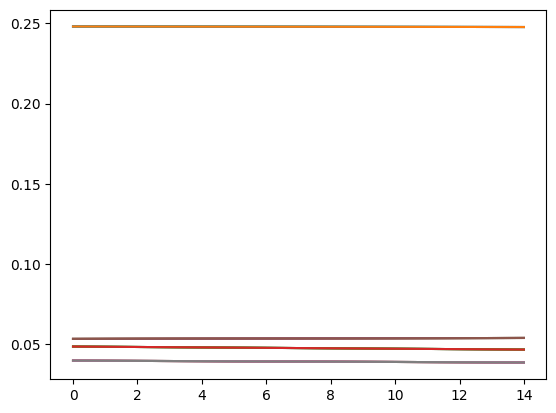

In [30]:
plt.plot(t,np.real(np.array(resps1)))#,t,np.angle(resps1/resps1[0]))
plt.plot(t,np.real(np.array(resps2)))
plt.plot(t,np.imag(np.array(resps1)))#,t,np.angle(resps1/resps1[0]))
plt.plot(t,np.imag(np.array(resps2)))



In [31]:
theta_1[-1]-theta_1[0]

np.float64(0.0012552025442424952)